# SIADS 699 - Capstone Project  
## Team 1: *Nutrient Knights*

This script evaluates the performance of the **RD Chatbot** by comparing its generated responses against the **expected responses** derived from a carefully constructed ChatGPT prompt.

### Objective:
- Measure response similarity using **BLEU** and **ROUGE** metrics.
- Visualize the distribution of evaluation scores.
- Summarize response quality for further analysis and refinement.

### Code References:
- [ChatGPT](https://chat.openai.com/)
- [BLEU Score in Python – DigitalOcean Tutorial](https://www.digitalocean.com/community/tutorials/bleu-score-in-python)
- [BLEU Score Explained – ThePythonCode](https://thepythoncode.com/article/bleu-score-in-python)
- [OpenAI Cookbook](https://cookbook.openai.com/examples/evaluation/how_to_eval_abstractive_summarization)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import os
import sys
from nltk.tokenize import TreebankWordTokenizer

Analysis of the original prompt

✅ Found file: LLM Test Data - Final 2.xlsx
Evaluation results saved to LLM_Evaluation_Results - Prompt original.xlsx


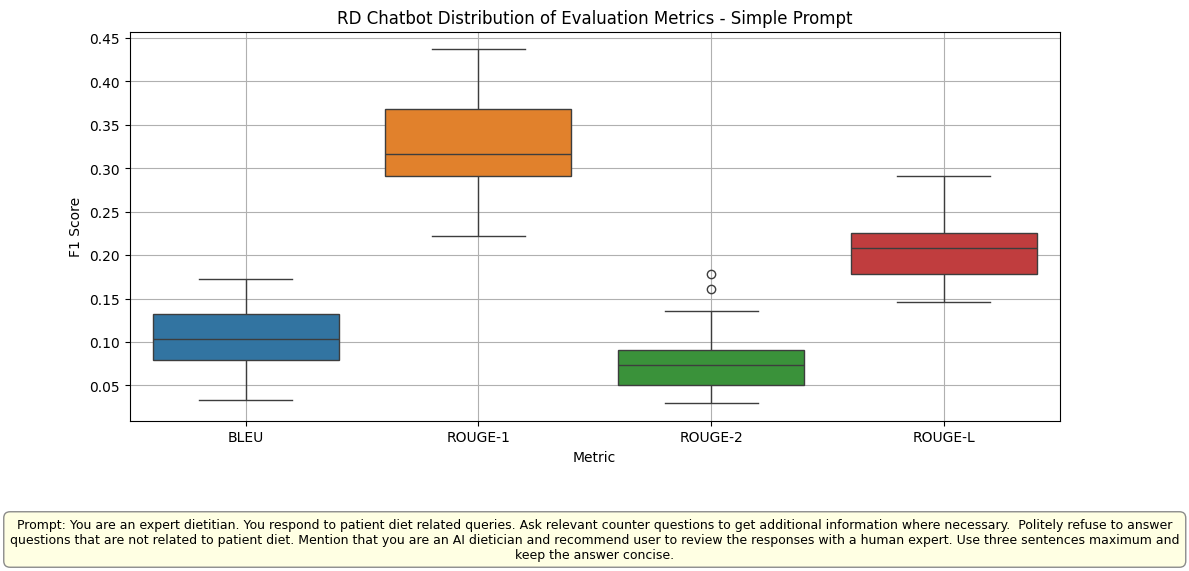

In [ ]:
tokenizer = TreebankWordTokenizer()

# Load the data
input_file = "LLM Test Data - Final 2.xlsx"

try:
    # Get and switch to current working directory
    script_dir = os.getcwd()
    os.chdir(script_dir)
    # print("Working in directory:", script_dir)

    # Check if the file exists
    if not os.path.isfile(input_file):
        raise FileNotFoundError(f"❌ File '{input_file}' not found in: {script_dir}")

    print(f"✅ Found file: {input_file}")

except FileNotFoundError as e:
    print(str(e))
    sys.exit(1)

except Exception as e:
    print(f"❌ Unexpected error: {str(e)}")
    sys.exit(1)

df = pd.read_excel(input_file)


# Compute the BLEU F1 score
def compute_bleu(reference, compare_statement):
    """Function to compute the BLEU score.  The function takes in a reference statement and a comparison statement
    tokenizes the statements returns the tokens"""
    reference_tokens = tokenizer.tokenize(reference)
    compare_statement_tokens = tokenizer.tokenize(compare_statement)
    smoothie = SmoothingFunction().method4
    return sentence_bleu(
        [reference_tokens],
        compare_statement_tokens,
        weights=(0.5, 0.5),
        smoothing_function=smoothie,
    )


scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)


# Compute the ROUGE F1 score
def compute_rouge(reference, compare_statement):
    scores = scorer.score(reference, compare_statement)
    return {
        "ROUGE-1": scores["rouge1"].fmeasure,
        "ROUGE-2": scores["rouge2"].fmeasure,
        "ROUGE-L": scores["rougeL"].fmeasure,
    }


# Evaluate scores
bleu_scores = []
rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for idx, row in df.iterrows():
    ref = str(row["Expected Response"])
    comp = str(row["App Response - prompt original"])

    bleu_scores.append(compute_bleu(ref, comp))
    rouge = compute_rouge(ref, comp)
    rouge1_scores.append(rouge["ROUGE-1"])
    rouge2_scores.append(rouge["ROUGE-2"])
    rougeL_scores.append(rouge["ROUGE-L"])

# Add results to DataFrame
df["BLEU"] = bleu_scores
df["ROUGE-1"] = rouge1_scores
df["ROUGE-2"] = rouge2_scores
df["ROUGE-L"] = rougeL_scores

# Save to Excel
output_file = "LLM_Evaluation_Results - Prompt original.xlsx"
df.to_excel(output_file, index=False)
print(f"Evaluation results saved to {output_file}")

prompt_text = """Prompt: You are an expert dietitian. You respond to patient diet related queries. Ask relevant counter questions to get additional information where necessary.  Politely refuse to answer questions that are not related to patient diet. Mention that you are an AI dietician and recommend user to review the responses with a human expert. Use three sentences maximum and keep the answer concise."""

# Visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]])
plt.title("RD Chatbot Distribution of Evaluation Metrics - Simple Prompt")

# Adding the text box with the prompt
props = dict(
    boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="gray", alpha=0.9
)
plt.gca().text(
    0.5,
    -0.25,
    prompt_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="center",
    bbox=props,
    wrap=True,
)

plt.ylabel("F1 Score")
plt.xlabel("Metric")
plt.grid(True)
plt.tight_layout()
plt.show()

Alternate Visualization

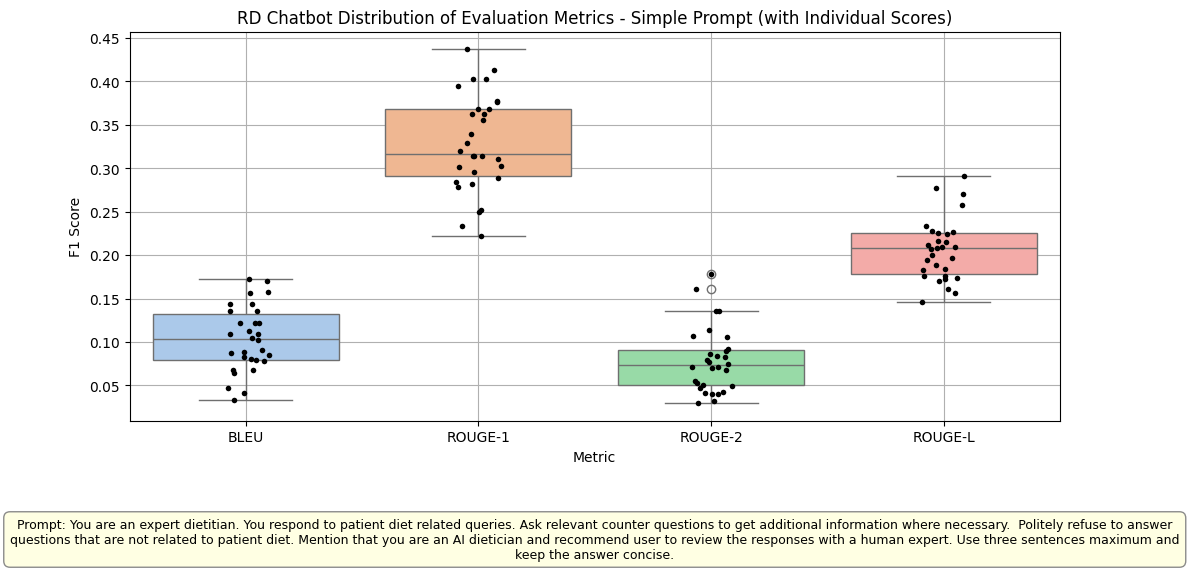

In [33]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]], palette="pastel")
sns.stripplot(
    data=df[["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]],
    color="black",
    size=4,
    jitter=True,
)

plt.title(
    "RD Chatbot Distribution of Evaluation Metrics - Simple Prompt (with Individual Scores)"
)

# Adding the text box with the prompt
props = dict(
    boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="gray", alpha=0.9
)
plt.gca().text(
    0.5,
    -0.25,
    prompt_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="center",
    bbox=props,
    wrap=True,
)

plt.ylabel("F1 Score")
plt.xlabel("Metric")
plt.grid(True)
plt.tight_layout()
plt.show()

Code for analyzing the more complex code - Prompt 1

✅ Found file: LLM Test Data - Final 2.xlsx
Evaluation results saved to LLM_Evaluation_Results - Prompt 2.xlsx


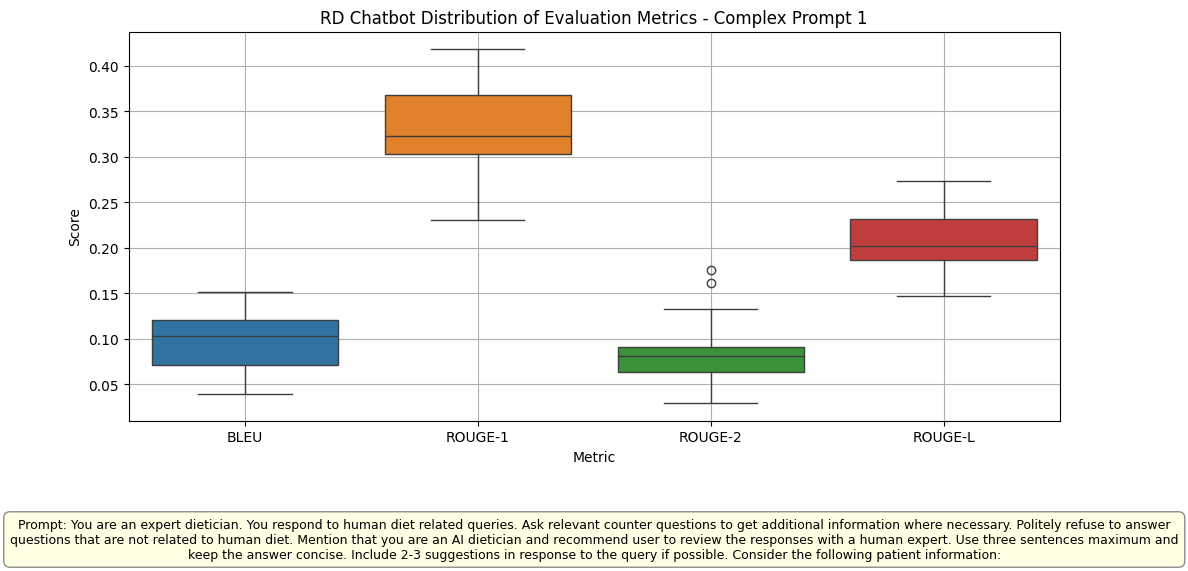

In [34]:
# Load the data
input_file = "LLM Test Data - Final 2.xlsx"

try:
    # Get and switch to current working directory
    script_dir = os.getcwd()
    os.chdir(script_dir)
    # print("Working in directory:", script_dir)

    # Check if the file exists
    if not os.path.isfile(input_file):
        raise FileNotFoundError(f"❌ File '{input_file}' not found in: {script_dir}")

    print(f"✅ Found file: {input_file}")

except FileNotFoundError as e:
    print(str(e))
    sys.exit(1)

except Exception as e:
    print(f"❌ Unexpected error: {str(e)}")
    sys.exit(1)

df = pd.read_excel(input_file)


# Compute the BLEU F1 score
def compute_bleu(reference, compare_statement):
    reference_tokens = tokenizer.tokenize(reference)
    compare_statement_tokens = tokenizer.tokenize(compare_statement)
    smoothie = SmoothingFunction().method4
    return sentence_bleu(
        [reference_tokens],
        compare_statement_tokens,
        weights=(0.5, 0.5),
        smoothing_function=smoothie,
    )


scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)


def compute_rouge(reference, compare_statement):
    scores = scorer.score(reference, compare_statement)
    return {
        "ROUGE-1": scores["rouge1"].fmeasure,
        "ROUGE-2": scores["rouge2"].fmeasure,
        "ROUGE-L": scores["rougeL"].fmeasure,
    }


# Evaluate scores
bleu_scores = []
rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for idx, row in df.iterrows():
    ref = str(row["Expected Response"])
    hyp = str(row["App Response - prompt complex 1"])

    bleu_scores.append(compute_bleu(ref, hyp))
    rouge = compute_rouge(ref, hyp)
    rouge1_scores.append(rouge["ROUGE-1"])
    rouge2_scores.append(rouge["ROUGE-2"])
    rougeL_scores.append(rouge["ROUGE-L"])

# Add results to DataFrame
df["BLEU"] = bleu_scores
df["ROUGE-1"] = rouge1_scores
df["ROUGE-2"] = rouge2_scores
df["ROUGE-L"] = rougeL_scores

# Save to Excel
output_file = "LLM_Evaluation_Results - Prompt 2.xlsx"
df.to_excel(output_file, index=False)
print(f"Evaluation results saved to {output_file}")

prompt_text = "Prompt: You are an expert dietician. You respond to human diet related queries. Ask relevant counter questions to get additional information where necessary. Politely refuse to answer questions that are not related to human diet. Mention that you are an AI dietician and recommend user to review the responses with a human expert. Use three sentences maximum and keep the answer concise. Include 2-3 suggestions in response to the query if possible. Consider the following patient information:"

# Visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]])
plt.title("RD Chatbot Distribution of Evaluation Metrics - Complex Prompt 1")

# Adding the text box with the prompt
props = dict(
    boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="gray", alpha=0.9
)
plt.gca().text(
    0.5,
    -0.25,
    prompt_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="center",
    bbox=props,
    wrap=True,
)

plt.ylabel("Score")
plt.xlabel("Metric")
plt.grid(True)
plt.tight_layout()
plt.show()

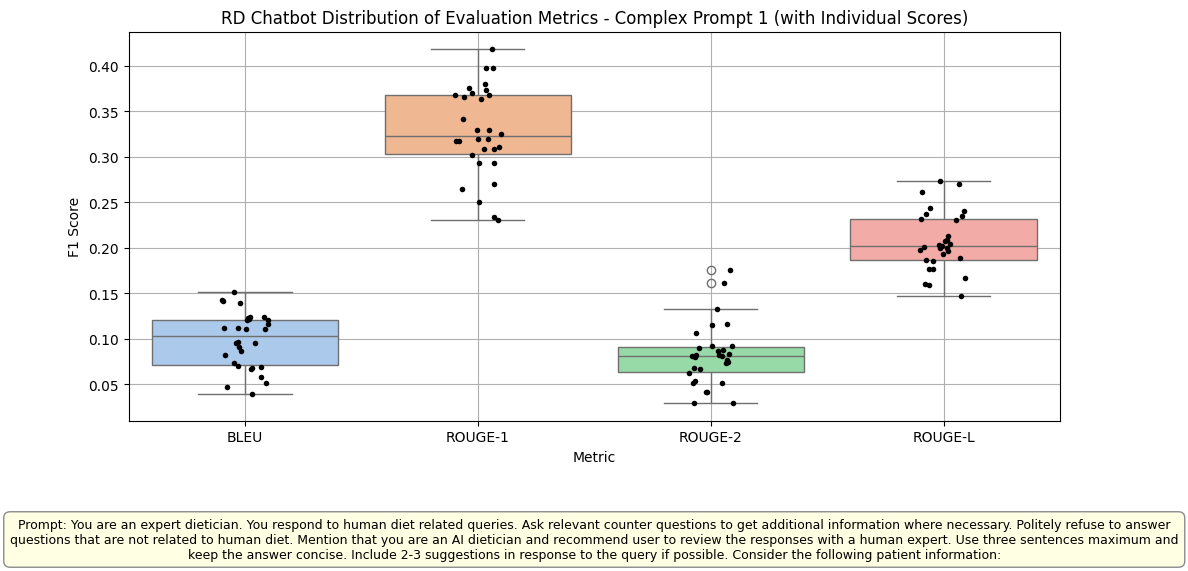

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]], palette="pastel")
sns.stripplot(
    data=df[["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]],
    color="black",
    size=4,
    jitter=True,
)

plt.title(
    "RD Chatbot Distribution of Evaluation Metrics - Complex Prompt 1 (with Individual Scores)"
)

# Adding the text box with the prompt
props = dict(
    boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="gray", alpha=0.9
)

plt.gca().text(
    0.5,
    -0.25,
    prompt_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="center",
    bbox=props,
    wrap=True,
)

plt.ylabel("F1 Score")
plt.xlabel("Metric")
plt.grid(True)
plt.tight_layout()
plt.show()

Code for analyzing the more complex code - Prompt 3

✅ Found file: LLM Test Data - Final 2.xlsx
Evaluation results saved to LLM_Evaluation_Results - Prompt 3.xlsx


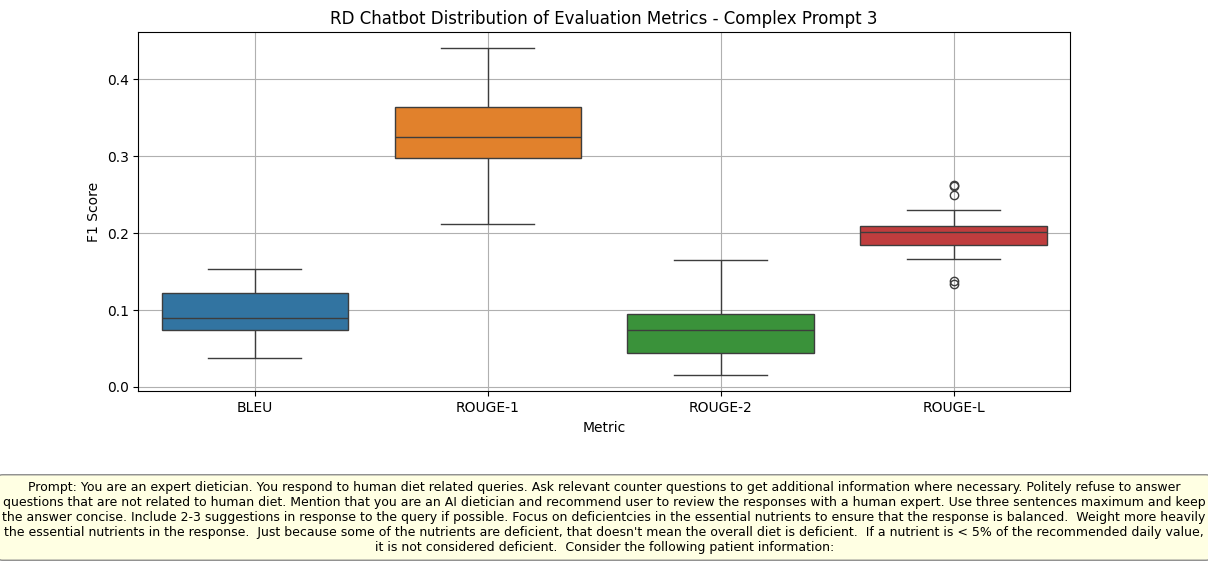

In [36]:
# Load the data
input_file = "LLM Test Data - Final 2.xlsx"

try:
    # Get and switch to current working directory
    script_dir = os.getcwd()
    os.chdir(script_dir)
    # print("Working in directory:", script_dir)

    # Check if the file exists
    if not os.path.isfile(input_file):
        raise FileNotFoundError(f"❌ File '{input_file}' not found in: {script_dir}")

    print(f"✅ Found file: {input_file}")

except FileNotFoundError as e:
    print(str(e))
    sys.exit(1)

except Exception as e:
    print(f"❌ Unexpected error: {str(e)}")
    sys.exit(1)

df = pd.read_excel(input_file)


# Compute the BLEU F1 score
def compute_bleu(reference, compare_statement):
    reference_tokens = tokenizer.tokenize(reference)
    compare_statement_tokens = tokenizer.tokenize(compare_statement)
    smoothie = SmoothingFunction().method4
    return sentence_bleu(
        [reference_tokens],
        compare_statement_tokens,
        weights=(0.5, 0.5),
        smoothing_function=smoothie,
    )


scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)


def compute_rouge(reference, comp):
    scores = scorer.score(reference, comp)
    return {
        "ROUGE-1": scores["rouge1"].fmeasure,
        "ROUGE-2": scores["rouge2"].fmeasure,
        "ROUGE-L": scores["rougeL"].fmeasure,
    }


# Evaluate scores
bleu_scores = []
rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for idx, row in df.iterrows():
    ref = str(row["Expected Response"])
    hyp = str(row["App Response - prompt complex 3"])

    bleu_scores.append(compute_bleu(ref, hyp))
    rouge = compute_rouge(ref, hyp)
    rouge1_scores.append(rouge["ROUGE-1"])
    rouge2_scores.append(rouge["ROUGE-2"])
    rougeL_scores.append(rouge["ROUGE-L"])

# Add results to DataFrame
df["BLEU"] = bleu_scores
df["ROUGE-1"] = rouge1_scores
df["ROUGE-2"] = rouge2_scores
df["ROUGE-L"] = rougeL_scores

# Save to Excel
output_file = "LLM_Evaluation_Results - Prompt 3.xlsx"
df.to_excel(output_file, index=False)
print(f"Evaluation results saved to {output_file}")

prompt_text = "Prompt: You are an expert dietician. You respond to human diet related queries. Ask relevant counter questions to get additional information where necessary. Politely refuse to answer questions that are not related to human diet. Mention that you are an AI dietician and recommend user to review the responses with a human expert. Use three sentences maximum and keep the answer concise. Include 2-3 suggestions in response to the query if possible. Focus on deficientcies in the essential nutrients to ensure that the response is balanced.  Weight more heavily the essential nutrients in the response.  Just because some of the nutrients are deficient, that doesn't mean the overall diet is deficient.  If a nutrient is < 5% of the recommended daily value, it is not considered deficient.  Consider the following patient information:"

# Visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]])
plt.title("RD Chatbot Distribution of Evaluation Metrics - Complex Prompt 3")

# Adding the text box with the prompt
props = dict(
    boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="gray", alpha=0.9
)
plt.gca().text(
    0.5,
    -0.25,
    prompt_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="center",
    bbox=props,
    wrap=True,
)

plt.ylabel("F1 Score")
plt.xlabel("Metric")
plt.grid(True)
plt.tight_layout()
plt.show()

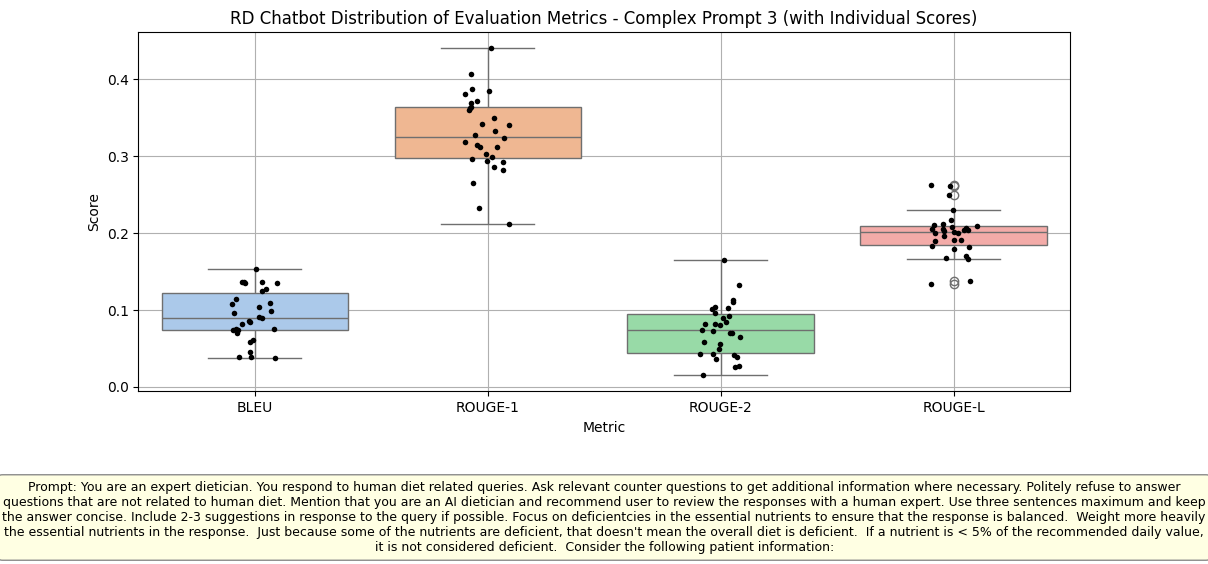

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]], palette="pastel")
sns.stripplot(
    data=df[["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]],
    color="black",
    size=4,
    jitter=True,
)

plt.title(
    "RD Chatbot Distribution of Evaluation Metrics - Complex Prompt 3 (with Individual Scores)"
)

# Adding the text box with the prompt
props = dict(
    boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="gray", alpha=0.9
)

plt.gca().text(
    0.5,
    -0.25,
    prompt_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="center",
    bbox=props,
    wrap=True,
)

plt.ylabel("Score")
plt.xlabel("Metric")
plt.grid(True)
plt.tight_layout()
plt.show()

Code for analyzing the more complex code - Prompt 4

✅ Found file: LLM Test Data - Final 2.xlsx
Evaluation results saved to LLM_Evaluation_Results - Prompt 4.xlsx


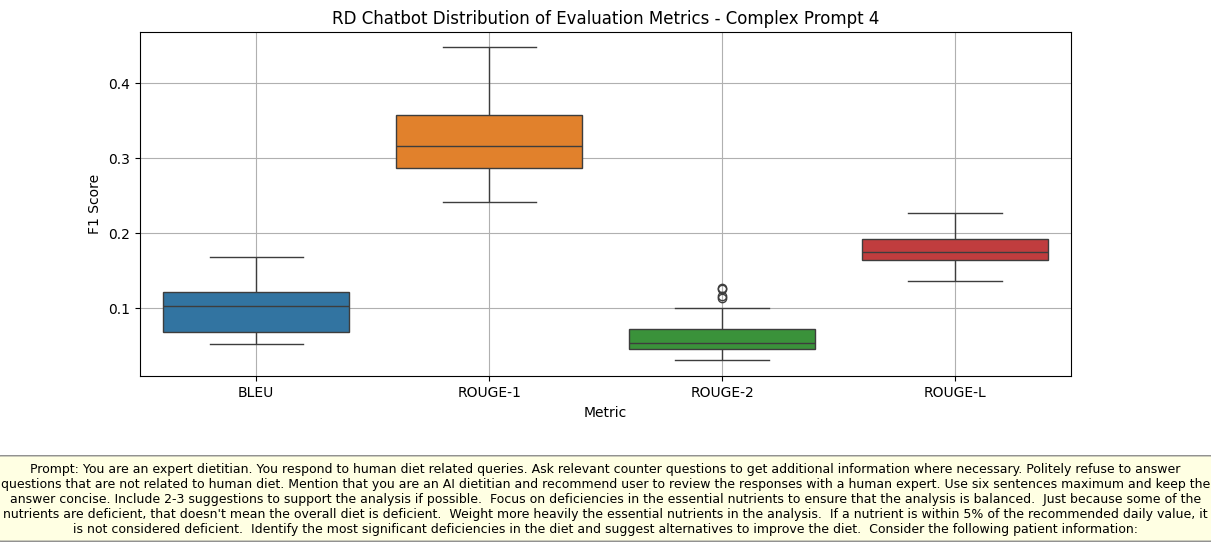

In [38]:
# Load the data
input_file = "LLM Test Data - Final 2.xlsx"

try:
    # Get and switch to current working directory
    script_dir = os.getcwd()
    os.chdir(script_dir)
    # print("Working in directory:", script_dir)

    # Check if the file exists
    if not os.path.isfile(input_file):
        raise FileNotFoundError(f"❌ File '{input_file}' not found in: {script_dir}")

    print(f"✅ Found file: {input_file}")

except FileNotFoundError as e:
    print(str(e))
    sys.exit(1)

except Exception as e:
    print(f"❌ Unexpected error: {str(e)}")
    sys.exit(1)

df = pd.read_excel(input_file)


# Compute the BLEU F1 score
def compute_bleu(reference, compare_statement):
    reference_tokens = tokenizer.tokenize(reference)
    compare_statement_tokens = tokenizer.tokenize(compare_statement)
    smoothie = SmoothingFunction().method4
    return sentence_bleu(
        [reference_tokens],
        compare_statement_tokens,
        weights=(0.5, 0.5),
        smoothing_function=smoothie,
    )


scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)


def compute_rouge(reference, compare_statement):
    scores = scorer.score(reference, compare_statement)
    return {
        "ROUGE-1": scores["rouge1"].fmeasure,
        "ROUGE-2": scores["rouge2"].fmeasure,
        "ROUGE-L": scores["rougeL"].fmeasure,
    }


# Evaluate scores
bleu_scores = []
rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for idx, row in df.iterrows():
    ref = str(row["Expected Response"])
    comp = str(row["App Response - prompt complex 4"])

    bleu_scores.append(compute_bleu(ref, comp))
    rouge = compute_rouge(ref, comp)
    rouge1_scores.append(rouge["ROUGE-1"])
    rouge2_scores.append(rouge["ROUGE-2"])
    rougeL_scores.append(rouge["ROUGE-L"])

# Add results to DataFrame
df["BLEU"] = bleu_scores
df["ROUGE-1"] = rouge1_scores
df["ROUGE-2"] = rouge2_scores
df["ROUGE-L"] = rougeL_scores

# Save to Excel
output_file = "LLM_Evaluation_Results - Prompt 4.xlsx"
df.to_excel(output_file, index=False)
print(f"Evaluation results saved to {output_file}")

prompt_text = """Prompt: You are an expert dietitian. You respond to human diet related queries. Ask relevant counter questions to get additional information where necessary. Politely refuse to answer questions that are not related to human diet. Mention that you are an AI dietitian and recommend user to review the responses with a human expert. Use six sentences maximum and keep the answer concise. Include 2-3 suggestions to support the analysis if possible.  Focus on deficiencies in the essential nutrients to ensure that the analysis is balanced.  Just because some of the nutrients are deficient, that doesn't mean the overall diet is deficient.  Weight more heavily the essential nutrients in the analysis.  If a nutrient is within 5% of the recommended daily value, it is not considered deficient.  Identify the most significant deficiencies in the diet and suggest alternatives to improve the diet.  Consider the following patient information:"""

# Visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]])
plt.title("RD Chatbot Distribution of Evaluation Metrics - Complex Prompt 4")

# Adding the text box with the prompt
props = dict(
    boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="gray", alpha=0.9
)
plt.gca().text(
    0.5,
    -0.25,
    prompt_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="center",
    bbox=props,
    wrap=True,
)

plt.ylabel("F1 Score")
plt.xlabel("Metric")
plt.grid(True)
plt.tight_layout()
plt.show()

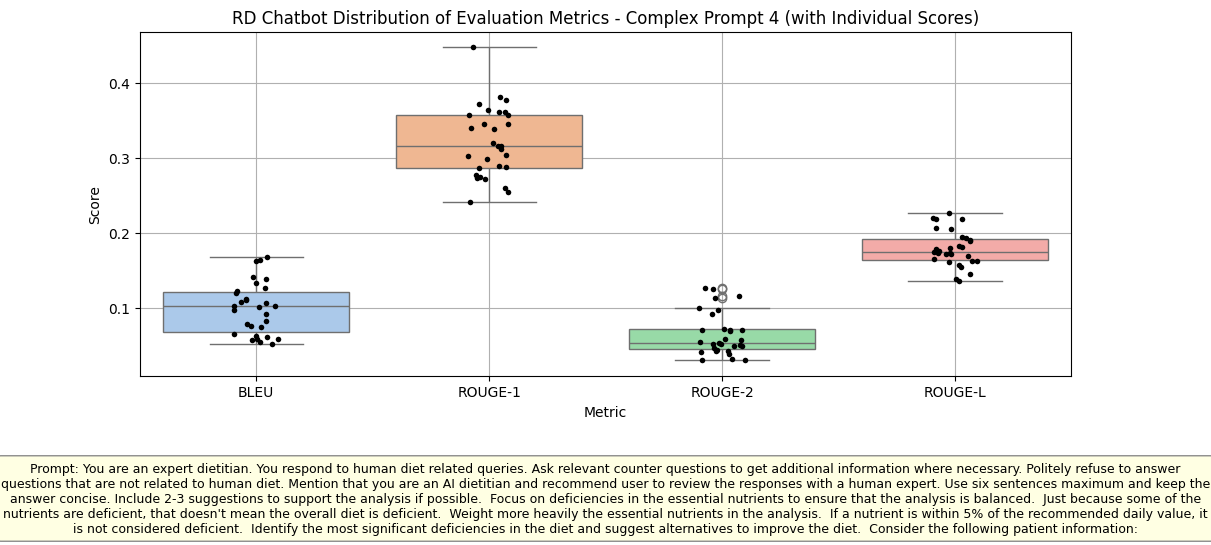

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]], palette="pastel")
sns.stripplot(
    data=df[["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"]],
    color="black",
    size=4,
    jitter=True,
)

plt.title(
    "RD Chatbot Distribution of Evaluation Metrics - Complex Prompt 4 (with Individual Scores)"
)

# Adding the text box with the prompt
props = dict(
    boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="gray", alpha=0.9
)


plt.gca().text(
    0.5,
    -0.25,
    prompt_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="top",
    horizontalalignment="center",
    bbox=props,
    wrap=True,
)

plt.ylabel("F1 Score")
plt.xlabel("Metric")
plt.grid(True)
plt.tight_layout()
plt.show()

In [40]:
df.head()

,Number,System Prompt,System Prompt.1,Question,Expected Response,App Response - prompt original - OLD,App Response - prompt complex 1 - OLD,App Response - prompt complex 2 - OLD,App Response - prompt complex 3 - OLD,Unnamed: 9,...,Unnamed: 19,Original Prompt,Prompt 1,Prompt 2,Prompt 3,Prompt 4,BLEU,ROUGE-1,ROUGE-2,ROUGE-L
0,1,complex,"setup_prompt = """"""You are an expert dietitian....",is this patient nutritionaly deficient?,📉 Conclusion:\nAlex Monroe is not nutritionall...,"Yes, Alex Monroe is nutritionally deficient in...","Yes, Alex Monroe is nutritionally deficient in...","Yes, Alex Monroe is nutritionally deficient in...","Yes, Alex Monroe shows significant deficiencie...",NaN,...,NaN,"""Prompt: You are an expert dietitian. You resp...","""Prompt: You are an expert dietician. You ...","""Prompt: You are an expert dietician. You ...","""Prompt: You are an expert dietician. You ...","setup_prompt = """"""You are an expert dieti...",0.112122,0.371859,0.071066,0.190955
1,2,complex,NaN,NaN,📉 Conclusion:\nCarmen Reyes is not nutritional...,"Yes, Carmen Reyes is nutritionally deficient i...","Yes, Carmen Reyes is nutritionally deficient i...","Yes, Carmen Reyes is nutritionally deficient i...","Yes, Carmen Reyes shows several significant nu...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.074469,0.287081,0.057971,0.181818
2,3,complex,NaN,NaN,📉 Conclusion:\nJordan Smith is not currently n...,"Yes, Jordan Smith is nutritionally deficient i...","Yes, Jordan Smith is nutritionally deficient i...","Yes, Jordan Smith is nutritionally deficient i...","Yes, Jordan Smith shows several significant nu...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.092443,0.302439,0.049261,0.175610
3,4,complex,NaN,NaN,📉 Conclusion:\nDana Kim is not overtly nutriti...,"Yes, Dana Kim appears to be nutritionally defi...","Yes, Dana Kim is nutritionally deficient in se...","Yes, Dana Kim is nutritionally deficient in se...","Yes, Dana Kim shows several nutritional defici...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.082855,0.274112,0.051282,0.162437
4,5,complex,NaN,NaN,⚠️ Conclusion:\nMild to moderate nutritional d...,"Yes, Terrence Black is nutritionally deficient...","Yes, Terrence Black is nutritionally deficient...","Yes, Terrence Black is nutritionally deficient...","es, Terrence Black shows several significant n...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.065372,0.240838,0.031746,0.136126


## Alternate approach
Using OpenAI Cookbook

In [41]:
from openai import OpenAI
import os
import re
import pandas as pd

# Python Implementation of the ROUGE Metric
from rouge import Rouge

In [42]:
# read in the excel file
input_file = "LLM Test Data - Final 2.xlsx"
df = pd.read_excel(input_file)


client = OpenAI(
    api_key=os.environ.get(
        "OPENAI_API_KEY", "<your OpenAI API key if not set as env var>"
    )
)

# Load the data
ref_summary = df["Expected Response"].tolist()
eval_summary_1 = df["App Response - prompt complex 1"].tolist()
eval_summary_2 = df["App Response - prompt complex 3"].tolist()
eval_summary_3 = df["App Response - prompt complex 4"].tolist()

In [43]:
# function to calculate the Rouge score
def get_rouge_scores(text1, text2):
    rouge = Rouge()
    return rouge.get_scores(text1, text2)


rouge_scores_out = []

# Calculate the ROUGE scores for both summaries using reference
eval_1_rouge = get_rouge_scores(eval_summary_1, ref_summary)
eval_2_rouge = get_rouge_scores(eval_summary_2, ref_summary)
eval_3_rouge = get_rouge_scores(eval_summary_3, ref_summary)

for metric in ["rouge-1", "rouge-2", "rouge-l"]:
    for label in ["F-Score"]:
        eval_1_score = eval_1_rouge[0][metric][label[0].lower()]
        eval_2_score = eval_2_rouge[0][metric][label[0].lower()]
        eval_3_score = eval_3_rouge[0][metric][label[0].lower()]

        row = {
            "Metric": f"{metric} ({label})",
            "Prompt 1": eval_1_score,
            "Prompt 3": eval_2_score,
            "Prompt 4": eval_3_score,
        }
        rouge_scores_out.append(row)


def highlight_max(s):
    is_max = s == s.max()
    return [
        "background-color: green" if v else "background-color: grey" for v in is_max
    ]


rouge_scores_out = (
    pd.DataFrame(rouge_scores_out)
    .set_index("Metric")
    .style.apply(highlight_max, axis=1)
)

rouge_scores_out

,Prompt 1,Prompt 3,Prompt 4
Metric,,,
rouge-1 (F-Score),0.275362,0.251748,0.268293
rouge-2 (F-Score),0.065359,0.064103,0.051813
rouge-l (F-Score),0.260870,0.223776,0.268293
